In [1]:
import torch
import matplotlib.pyplot as plt
import scienceplots
scienceplots.plt.style.use("science")

In [2]:
def soft_threshold(x, thresh):
    return torch.sign(x) * torch.clamp(torch.abs(x) - thresh, min=0.0)


def estimate_lipschitz_constant(X, n_iter=50):
    _, d = X.shape

    v = torch.randn(d, dtype=X.dtype, device=X.device)
    v = v / torch.norm(v)

    for _ in range(n_iter):
        Xv = X @ v
        XtXv = X.T @ Xv

        norm_XtXv = torch.norm(XtXv)
        if norm_XtXv.item() == 0.0:
            return torch.tensor(0.0, dtype=X.dtype, device=X.device)

        v = XtXv / norm_XtXv

    Xv = X @ v
    L = torch.dot(Xv, Xv) / X.shape[0]
    return L


def fista_lasso(
    X,
    y,
    lam,
    max_iter=100,
    n_iter_lipschitz=50,
    tol=1e-6,
    device="cpu",
    verbose=False,
    lr=None,
    return_history=False,
) -> dict:
    X = torch.as_tensor(X, dtype=torch.float32, device=device)
    y = torch.as_tensor(y, dtype=torch.float32, device=device)

    if y.ndim == 2 and y.shape[1] == 1:
        y = y[:, 0]

    n, d = X.shape

    w = torch.zeros(d, dtype=torch.float32, device=device)
    z = w.clone()
    t = torch.tensor(1.0, dtype=torch.float32, device=device)

    # Lipschitz定数 L = ||X||_2^2 / n
    if lr is None:
        if verbose:
            print("Estimating Lipschitz constant...")
        L = estimate_lipschitz_constant(X, n_iter=n_iter_lipschitz)
        lr = 1.0 / L
        if verbose:
            print(f"Estimated Lipschitz constant: {L:.4f}, Learning rate: {lr:.4f}")


    history = []

    for k in range(max_iter):
        grad = X.T @ (X @ z - y) / n
        w_new = soft_threshold(z - lr * grad, lr * lam)

        t_new = (1.0 + torch.sqrt(1.0 + 4.0 * t * t)) / 2.0
        z = w_new + ((t - 1.0) / t_new) * (w_new - w)
        t = t_new

        diff = torch.norm(w_new - w)
        w = w_new

        if return_history or (verbose and k % 10 == 0):
            residual = X @ w - y
            loss_smooth = 0.5 * torch.sum(residual * residual) / n
            loss_l1 = lam * torch.sum(torch.abs(w))
            obj = loss_smooth + loss_l1

        if return_history:
            history.append(obj.item())

        if verbose and k % 10 == 0:
            print(
                f"Iter {k}: Objective={obj.item():.4f}, Loss={loss_smooth.item():.4f}, L1={loss_l1.item():.4f}, Diff={diff.item():.4e}"
            )

        if diff.item() < tol:
            break

    if return_history:
        return {"w": w, "history": history}
    else:
        return {"w": w}

In [3]:
torch.manual_seed(0)

n = 40_000
d = n // 4
k = n // 6

X = torch.bernoulli(0.5 * torch.ones(n, d)) * 2 - 1
w_true = torch.zeros(d)
w_true[:k] = torch.randn(k)
y = X @ w_true + 0.1 * torch.randn(n)

lam = 0.01

# By default, the learning rate is calculated based on the Lipschitz constant.
results = fista_lasso(
    X,
    y,
    lam,
    max_iter=50,
    tol=1e-7,
    verbose=True,
    return_history=True,
    n_iter_lipschitz=50,
)

Estimating Lipschitz constant...
Estimated Lipschitz constant: 2.2202, Learning rate: 0.4504
Iter 0: Objective=849.5841, Loss=819.1665, L1=30.4176, Diff=4.0966e+01
Iter 10: Objective=53.2371, Loss=0.4314, L1=52.8057, Diff=5.1917e-01
Iter 20: Objective=52.7413, Loss=0.4090, L1=52.3323, Diff=8.2192e-02
Iter 30: Objective=52.7368, Loss=0.4010, L1=52.3358, Diff=1.6283e-02
Iter 40: Objective=52.7367, Loss=0.3967, L1=52.3400, Diff=3.1228e-03


In [4]:
# Setting the learning rate manually to 0.1.
results2 = fista_lasso(
    X,
    y,
    lam,
    max_iter=50,
    tol=1e-7,
    verbose=True,
    lr=0.1,
    return_history=True,
)

Iter 0: Objective=2591.8970, Loss=2585.1438, L1=6.7532, Diff=9.0952e+00
Iter 10: Objective=98.2827, Loss=46.6826, L1=51.6001, Diff=4.0682e+00
Iter 20: Objective=56.1558, Loss=2.1667, L1=53.9891, Diff=8.4631e-01
Iter 30: Objective=53.3175, Loss=0.8805, L1=52.4370, Diff=4.1406e-01
Iter 40: Objective=52.9130, Loss=0.6889, L1=52.2241, Diff=1.6383e-01


In [5]:
w_hat = results["w"]

print("estimated w:")
print(w_hat)

print("mse:", torch.mean((w_hat - w_true) ** 2).item())
print(
    "cosine similarity:",
    torch.nn.functional.cosine_similarity(w_hat, w_true, dim=0).item(),
)
print("non-zero count:", torch.sum(w_hat != 0).item())
print("true non-zero count:", torch.sum(w_true != 0).item())

estimated w:
tensor([1.0944, 1.3983, 1.6275,  ..., 0.0000, 0.0000, -0.0000])
mse: 0.00011232840915909037
cosine similarity: 0.9999603033065796
non-zero count: 6684
true non-zero count: 6666


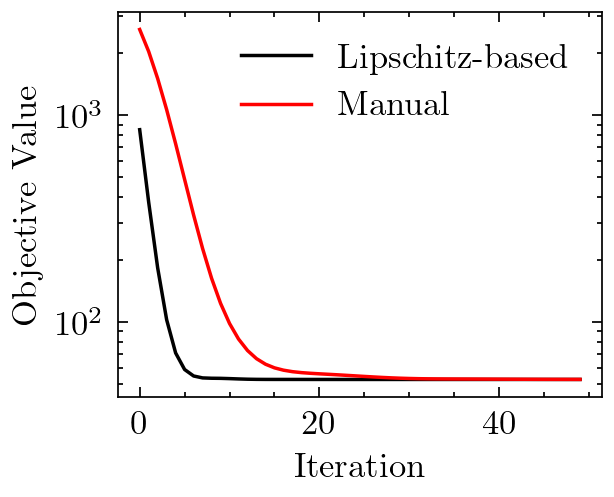

In [ ]:
history = results["history"]
history2 = results2["history"]

fig = plt.figure(figsize=(2.5,2), dpi=250)
ax = fig.add_subplot()
ax.plot(history2, label="Manual", color="k")
ax.plot(history, label="Lipschitz-based", color="r")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Value")
ax.set_yscale("log")
ax.legend()
plt.show()